# Forecasting Online Orders

The following script contains situations in which forecasting has been applied:
- Weather forecast
- Stock price analysis

Mocking data is used to mimick realistic scenarios. 

###### Disclaimer:
In accordance with legal regulations and ethical standards, we hereby assert that any data presented or mocked in this context is entirely fictitious and bears no affiliation with real, identifiable information. This simulation is purely hypothetical and has been created solely for illustrative and educational purposes. Any resemblance to actual persons, living or dead, or real events is purely coincidental and unintended.
***
Owner: s-bogers
***

## Weather forecast

Weather data is gathered from different places. Odense is used, out of these five, to make a model prediction based on the average temperature. 

<Axes: xlabel='time'>

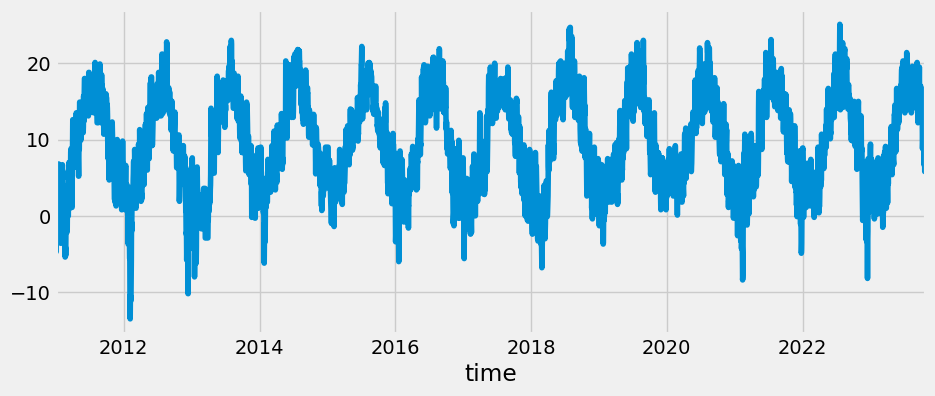

In [11]:
# Import Meteostat library and dependencies
from datetime import datetime
import matplotlib.pyplot as plt
from meteostat import Point, Daily
import pandas as pd

# Set time period
start = datetime(2011, 1, 1)
end = datetime(2023, 12, 31)

# Create Point 
locationAB = Point(57.046707, 9.935932) #Aalborg
locationAH = Point(56.15674, 10.21076) #Aarhus
locationEB = Point(55.47028, 8.45187) #Esbjerg
locationOD = Point(55.39594, 10.38831) #Odense
locationRK = Point(55.642639, 12.080449) #Roskilde
cities = ['Aalborg'
          , 'Aarhus'
          , 'Esbjerg'
          , 'Odense'
          , 'Roskilde']

# Get daily data for 2023
dataAB = Daily(locationAB, start, end)
dataAB = dataAB.fetch()
dataAH = Daily(locationAH, start, end)
dataAH = dataAH.fetch()
dataEB = Daily(locationEB, start, end)
dataEB = dataEB.fetch()
dataOD = Daily(locationOD, start, end)
dataOD = dataOD.fetch()
dataRK = Daily(locationRK, start, end)
dataRK = dataRK.fetch()

dfAB = pd.DataFrame(dataAB)
dfAB = dfAB[['tavg', 'wdir', 'wspd']]
dfAH = pd.DataFrame(dataAH)
dfAH = dfAH[['tavg', 'wdir', 'wspd']]
dfEB = pd.DataFrame(dataEB)
dfEB = dfEB[['tavg', 'wdir', 'wspd']]
dfOD = pd.DataFrame(dataOD)
dfOD = dfOD[['tavg', 'wdir', 'wspd']]
dfRK = pd.DataFrame(dataRK)
dfRK = dfRK[['tavg', 'wdir', 'wspd']]

result = pd.concat([dfAB, dfAH, dfEB, dfOD, dfRK], axis=1)

new_columns = pd.MultiIndex.from_product([cities,['tavg', 'wdir', 'wspd']])
result.columns = new_columns

result['Various', 'Day'] = result.index.dayofyear
result.fillna(method='ffill', inplace=True)
result = result['Odense']['tavg']

result.plot(figsize=(10,4))

ARMA RMSE:  10.360451892061539


ARIMA RMSE:  8.681923485131103


SARIMA RMSE:  9.717558532534547


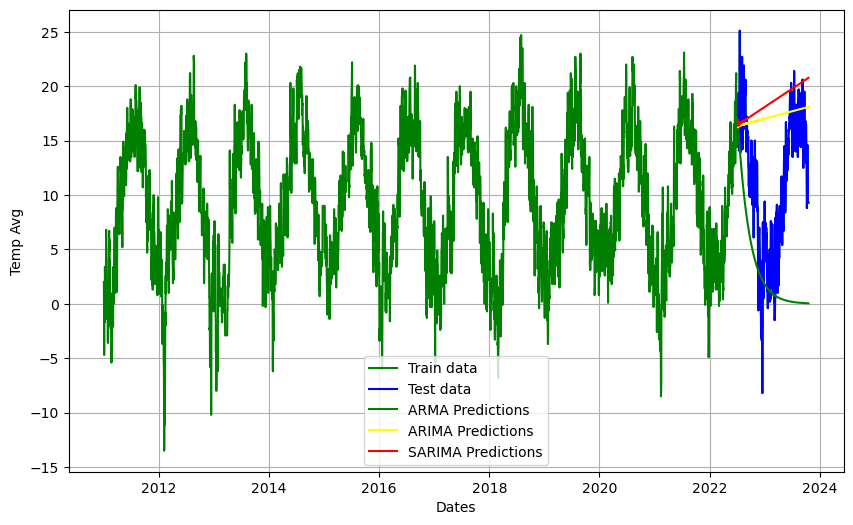

In [53]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Split train-test set manually
train_data, test_data = result[:int(len(result)*0.9)], result[int(len(result)*0.9):]

# Plot train-test using matplotlib.pyplot
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Temp Avg')
plt.plot(result, 'green', label='Train data')
plt.plot(test_data, 'blue', label='Test data')
plt.legend()

y = train_data
ARMAmodel = SARIMAX(y, order = (1, 0, 1))
ARMAmodel = ARMAmodel.fit()

y_pred = ARMAmodel.get_forecast(len(test_data.index))
y_pred_df = y_pred.conf_int(alpha = 0.05) 
y_pred_df["Predictions"] = ARMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = test_data.index
y_pred_out = y_pred_df["Predictions"] 

plt.plot(y_pred_out, color='green', label = 'ARMA Predictions')
plt.legend()
import numpy as np
from sklearn.metrics import mean_squared_error

arma_rmse = np.sqrt(mean_squared_error(test_data.values, y_pred_df["Predictions"]))
print("ARMA RMSE: ",arma_rmse)

from statsmodels.tsa.arima.model import ARIMA

ARIMAmodel = ARIMA(y, order = (5,2,3))
ARIMAmodel = ARIMAmodel.fit()

y_pred = ARIMAmodel.get_forecast(len(test_data.index))
y_pred_df = y_pred.conf_int(alpha = 0.05) 
y_pred_df["Predictions"] = ARIMAmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = test_data.index
y_pred_out = y_pred_df["Predictions"] 
plt.plot(y_pred_out, color='Yellow', label = 'ARIMA Predictions')
plt.legend()


import numpy as np
from sklearn.metrics import mean_squared_error

arma_rmse = np.sqrt(mean_squared_error(test_data.values, y_pred_df["Predictions"]))
print("ARIMA RMSE: ",arma_rmse)

SARIMAXmodel = SARIMAX(y, order = (5,2,3), seasonal_order=(2,0,0,12))
SARIMAXmodel = SARIMAXmodel.fit()

y_pred = SARIMAXmodel.get_forecast(len(test_data.index))
y_pred_df = y_pred.conf_int(alpha = 0.05) 
y_pred_df["Predictions"] = SARIMAXmodel.predict(start = y_pred_df.index[0], end = y_pred_df.index[-1])
y_pred_df.index = test_data.index
y_pred_out = y_pred_df["Predictions"] 
plt.plot(y_pred_out, color='Red', label = 'SARIMA Predictions')
plt.legend()

import numpy as np
from sklearn.metrics import mean_squared_error

arma_rmse = np.sqrt(mean_squared_error(test_data.values, y_pred_df["Predictions"]))
print("SARIMA RMSE: ",arma_rmse)

### Conclusion
Three models have been tested to see which one delivers the most accurate predictions, i.e. low RMSE value. Although the three are close, ARIMA provides the lowest value. Therefore, ARIMA would be the most suitable to use in this case.

Root Mean Square Error (RMSE) is a measure of the average deviation between predicted values and actual values in a dataset. It calculates the square root of the average of squared differences between predictions and actual outcomes, providing a single value that represents the overall accuracy of a predictive model. Lower RMSE values indicate better predictive accuracy.
***

## Stock Price Analysis

During difficult times of war, there are some parties who may benefit either way. Like defense company Lockheed Martin Corporation. In what way is their stock price influenced by today's time?

[*********************100%%**********************]  1 of 1 completed
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2012-01-03   82.120003   82.989998   81.769997   82.019997   57.430401   
2012-01-04   80.949997   81.449997   80.370003   80.910004   56.653160   
2012-01-05   80.660004   80.680000   79.050003   80.070000   56.065010   
2012-01-06   80.410004   80.410004   79.650002   79.980003   56.001972   
2012-01-09   80.349998   80.349998   79.760002   80.040001   56.044003   
...                ...         ...         ...         ...         ...   
2023-10-03  407.390015  407.500000  402.589996  403.829987  403.829987   
2023-10-04  400.660004  402.000000  397.109985  401.329987  401.329987   
2023-10-05  400.959991  401.429993  394.619995  397.350006  397.350006   
2023-10-06  395.399994  402.420013  393.769989  400.730011  400.730011   
2023-10-09  428.720001  436.600006  423.390

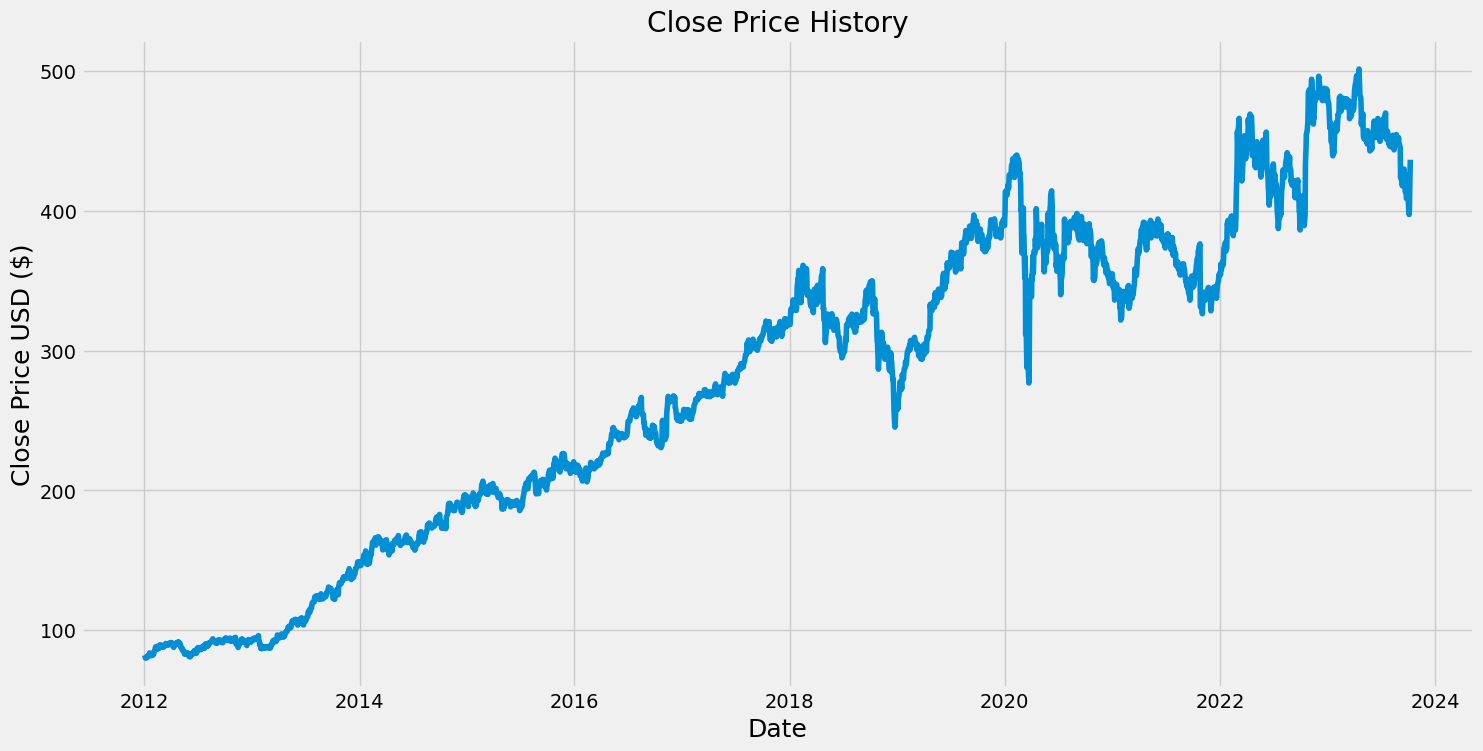

[array([0.00484065, 0.00220677, 0.00021355, 0.        , 0.00014237,
       0.00151864, 0.00189829, 0.00405761, 0.00365421, 0.00393896,
       0.0054576 , 0.00885081, 0.00664403, 0.00607455, 0.00536268,
       0.00415253, 0.00590845, 0.00484065, 0.00481693, 0.00555251,
       0.00839996, 0.00756945, 0.01093893, 0.01250503, 0.01577959,
       0.0181762 , 0.01905417, 0.01786773, 0.0195762 , 0.02009822,
       0.01649146, 0.01523384, 0.0190067 , 0.0170135 , 0.01812875,
       0.01971857, 0.02266093, 0.0223762 , 0.02069144, 0.02000332,
       0.01990841, 0.02021687, 0.02064399, 0.0185084 , 0.01893552,
       0.01993212, 0.02118976, 0.02140331, 0.02294568, 0.02477279,
       0.02448805, 0.02216263, 0.02273211, 0.02221008, 0.0224711 ,
       0.02235246, 0.02323041, 0.02529482, 0.02579312, 0.0230406 ])]
[0.02289821296418479]

19/19 [==============================] - 1s 10ms/step
RMSE of model is:  3.8587599573908626


C:\Users\sander.bogers\AppData\Local\Temp\ipykernel_33960\2118199026.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


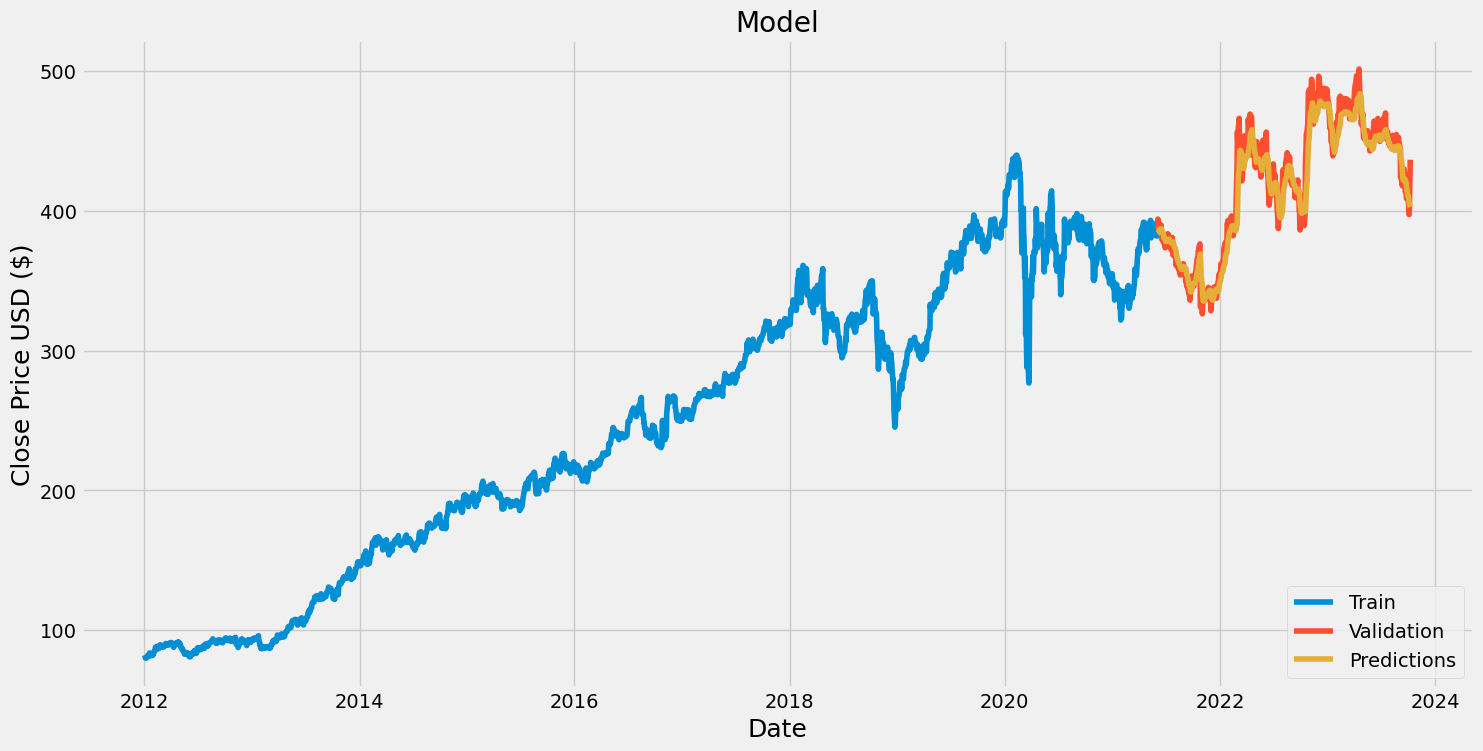

1/1 [==============================] - 0s 18ms/step
[[0.76589924]]
1/1 [==============================] - 0s 18ms/step
[[0.7637904]]
1/1 [==============================] - 0s 19ms/step
[[0.7623767]]
1/1 [==============================] - 0s 16ms/step
[[0.76130867]]
1/1 [==============================] - 0s 15ms/step
[[0.76040596]]
1/1 [==============================] - 0s 20ms/step
[[0.759577]]
1/1 [==============================] - 0s 17ms/step
[[0.7587749]]
1/1 [==============================] - 0s 18ms/step
[[0.75797725]]
1/1 [==============================] - 0s 16ms/step
[[0.7571728]]
1/1 [==============================] - 0s 16ms/step
[[0.75635755]]
1/1 [==============================] - 0s 17ms/step
[[0.75553054]]
1/1 [==============================] - 0s 19ms/step
[[0.75469255]]
1/1 [==============================] - 0s 17ms/step
[[0.7538452]]
1/1 [==============================] - 0s 18ms/step
[[0.7529908]]
1/1 [==============================] - 0s 17ms/step
[[0.7521314]]
1/1 

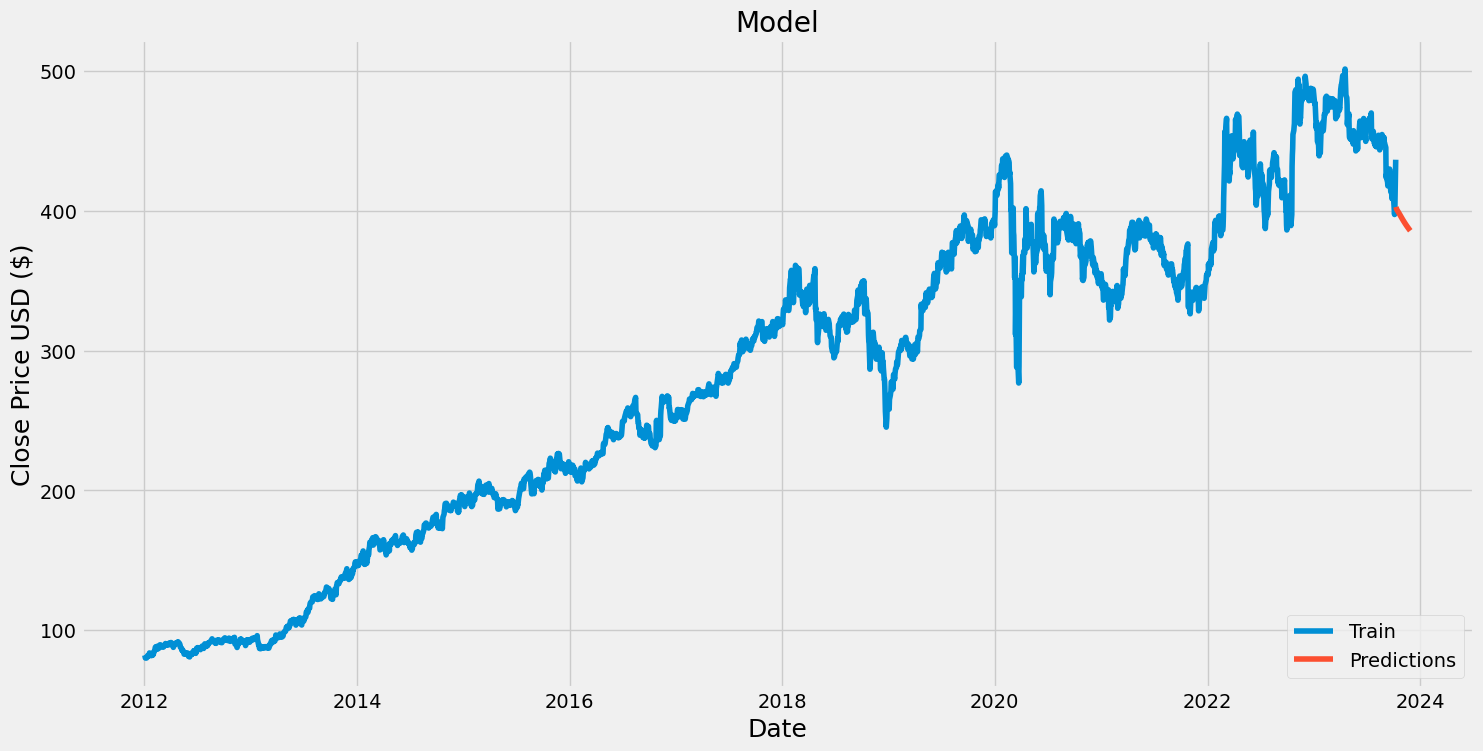

In [8]:
#Import the libraries
import math
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential 
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

#Get the stock quote
import yfinance as yf
df = yf.download('LMT', start = '2012-01-01', end='2023-10-10')

#Show the data
print(df)
#Get the number of rows and columns in the data set
print(df.shape)

#Visualize the closing price history
#We create a plot with name 'Close Price History'
plt.figure(figsize=(16,8))
plt.title('Close Price History')
#We give the plot the data (the closing price of our stock)
plt.plot(df['Close'])
#We label the axis
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
#We show the plot
plt.show()

#Create a new dataframe with only the 'Close' column
data = df.filter(['Close'])

#Convert the dataframe to a numpy array
dataset = data.values
#Get the number of rows to train the model on
training_data_len = math.ceil( len(dataset) * 0.8 )

#Scale the data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

#Create the training data set 
#Create the scaled training data set
train_data = scaled_data[0:training_data_len, :]

#Split the data into x_train and y_train data sets
x_train = []
y_train = []
#We create a loop
for i in range(60, len(train_data)):
  x_train.append(train_data[i-60:i, 0]) #Will conaint 60 values (0-59)
  y_train.append(train_data[i, 0]) #Will contain the 61th value (60)
  if i <= 60:
    print(x_train)
    print(y_train)
    print()

#Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

#Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

#Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

#Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

#Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

#Create the testing data set
#Create a new array containing scaled values from index 1738 to 2247
test_data = scaled_data[training_data_len - 60:]

#Create the data set x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
  x_test.append(test_data[i-60:i, 0])

#Convert the data to a numpy array
x_test = np.array(x_test)

#Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

#Get the model's predicted price values for the x_test data set
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

#Evaluate model (get the root mean quared error (RMSE))
rmse = np.sqrt( np.mean( predictions - y_test )**2 )
print("RMSE of model is: ", rmse)

#Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Validation', 'Predictions'], loc='lower right')
plt.show()

X_FUTURE = 50
predictions = np.array([])
last = x_test[-1]
for i in range(X_FUTURE):
  curr_prediction = model.predict(np.array([last]))
  print(curr_prediction)
  last = np.concatenate([last[1:], curr_prediction])
  predictions = np.concatenate([predictions, curr_prediction[0]])
predictions = scaler.inverse_transform([predictions])[0]

print("The upcoming predicted values are: ")
for x in predictions:
    print(x)

import datetime
from datetime import timedelta
dicts = []
curr_date = data.index[-1]
for i in range(X_FUTURE):
  curr_date = curr_date + timedelta(days=1)
  dicts.append({'Predictions':predictions[i], "Date": curr_date})

new_data = pd.DataFrame(dicts).set_index("Date")

#Plot the data
train = data
#Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(new_data['Predictions'])
plt.legend(['Train', 'Predictions'], loc='lower right')
plt.show()

### Conclusion
Although the closing stock price remains at a multi-year high time, a small decline is expected for the upcoming period. The RMSE value is 3.8587599573908626, to indicate a fairly trustworthy model.